In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

import pyunfold as pu

In [2]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [3]:
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))
tag = 'DomeC'

In [4]:
df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [5]:
# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

In [6]:
Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

In [7]:
# SET TIME-DEPENDENT FLUX MODEL

t_bins = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1] # time in years, with 0=present
t = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
t_scale = t/(Prop.t_bins[-1]-Prop.t_bins[Prop.i_start]) # time scaled from -1 to 0, with 0=present
t_samp = np.interp(Prop.z[Prop.i_start], Prop.z_bins, Prop.t_bins) - np.interp(Prop.z_samp, Prop.z_bins, Prop.t_bins) # time when sample depth ice started accumulating 14CO
t_step_bins = np.append([t_bins[-1]],np.append(t_samp[:-1],[t_bins[0]]))

f_poly = np.array([t_scale**i for i in range(len(Prop.z_samp))])

#f_step = np.array([1.*(t_scale<=-i/np.shape(Prop.S_mat)[-1])*(t_scale>-(i+1)/np.shape(Prop.S_mat)[-1]) for i in range(np.shape(Prop.S_mat)[-1])])
#f_step[-1,0] = 1. # couldn't find a way to define it that included this last value

i_t = np.reshape(np.arange(len(t)), (1,-1))
i_step = np.reshape(np.interp(t_step_bins, t_bins, np.arange(len(t_bins))), (-1,1))
f_step = (i_step[:-1]-i_t).clip(0,1) - (i_step[1:]-i_t).clip(0,1)

t_split = np.flip(np.append([t_bins[-1]],np.append((t_samp[1:-1]+t_samp[:-2])/2,[t_bins[0]])))

#t_split = np.linspace(t[0],t[-1],np.shape(Prop.S_mat)[-1], dtype=int)

f_interp = np.array([((t_split[i+1]-t)/(t_split[i+1]-t_split[i])*(t>=t_split[i])*(t<t_split[i+1]) if i!=len(t_split)-1 else 0.) + ((t-t_split[i-1])/(t_split[i]-t_split[i-1])*(t>t_split[i-1])*(t<t_split[i]) if i!=0 else 0.) for i in range(len(t_split))])
f_interp[-1,-1] = 1.

In [8]:
np.shape(f_step)

(10, 7283)

In [9]:
C_flow_poly = np.swapaxes(f_poly @ C_flow_response, 1,2)
C_flow_step = np.swapaxes(f_step @ C_flow_response, 1,2)
C_flow_interp = np.swapaxes(f_interp @ C_flow_response, 1,2)

In [10]:
C_poly = np.swapaxes(np.flip(f_poly,axis=-1) @ C_response, 1,2)
C_step = np.swapaxes(f_step @ C_response, 1,2)
C_interp = np.swapaxes(f_interp @ C_response, 1,2)

In [11]:
df = pd.read_csv('factors_2sigma_hull.csv', header=None)
f_factors = np.array([df[1],df[0]]).T
f_weights = np.ones(len(f_factors))

In [12]:
f_avg = np.average(f_factors, axis=0)

In [13]:
CO_poly = np.swapaxes(f_factors @ C_poly, 1,2)
CO_avg_poly = f_avg @ C_poly

CO_step = np.swapaxes(f_factors @ C_step, 1,2)
CO_avg_step = f_avg @ C_step

CO_interp = np.swapaxes(f_factors @ C_interp, 1,2)
CO_avg_interp = f_avg @ C_interp

In [14]:
CO_avg_inv_poly = np.linalg.inv(CO_avg_poly[0])
CO_avg_inv_step = np.linalg.inv(CO_avg_step[0])
CO_avg_inv_interp = np.linalg.inv(CO_avg_interp[0])

In [15]:
rel_err = 0.02

In [56]:
N = 10
s = np.random.normal(0,rel_err,(N, np.shape(CO_avg_poly)[-1]))
f_samp = np.random.rand(len(Prop.z_samp))*0.4+0.8
#f_samp = np.ones(len(Prop.z_samp))
#x = CO_avg_poly[0,0]*(1+s)
x = (f_samp @ CO_avg_interp[0])*(1+s)

In [57]:
(f_avg@C_flow_poly[0,0])

array([2.10085737e-02, 4.19984127e-02, 6.29695385e-02, ...,
       2.32559719e+01, 2.32548250e+01, 2.32536778e+01])

Text(0.5, 0, 'Depth [m]')

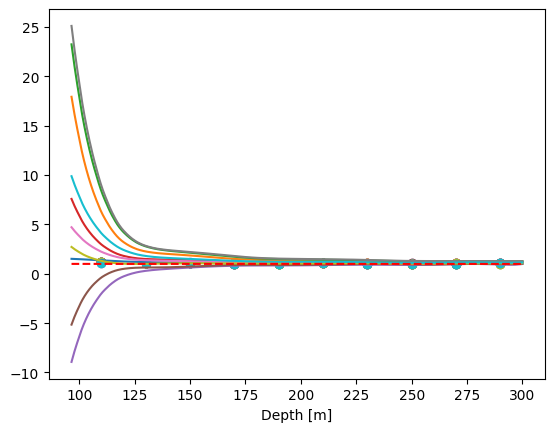

In [58]:
for X in x:
    plt.plot(Prop.z[Prop.i_start:],((X @ CO_avg_inv_poly) @ (f_avg @ C_flow_poly[0])) / (f_avg@C_flow_poly[0,0]))
    plt.scatter(Prop.z_samp,X/CO_avg_poly[0,0])
plt.plot(Prop.z[Prop.i_start:],f_avg@C_flow_poly[0,0]/(f_avg@C_flow_poly[0,0]),ls='--',c='r')
#plt.ylim(0.8,1.2)
plt.xlabel('Depth [m]')

Text(0.5, 0, 'Depth [m]')

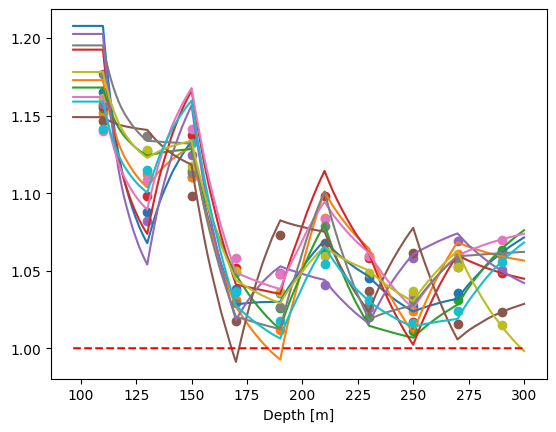

In [59]:
for X in x:
    plt.plot(Prop.z[Prop.i_start:],((X @ CO_avg_inv_step) @ (f_avg @ C_flow_step[0]))/(f_avg@C_flow_poly[0,0]))
    plt.scatter(Prop.z_samp,X/CO_avg_poly[0,0])
plt.plot(Prop.z[Prop.i_start:],f_avg@C_flow_poly[0,0]/(f_avg@C_flow_poly[0,0]),ls='--',c='r')
plt.xlabel('Depth [m]')

Text(0.5, 0, 'Depth [m]')

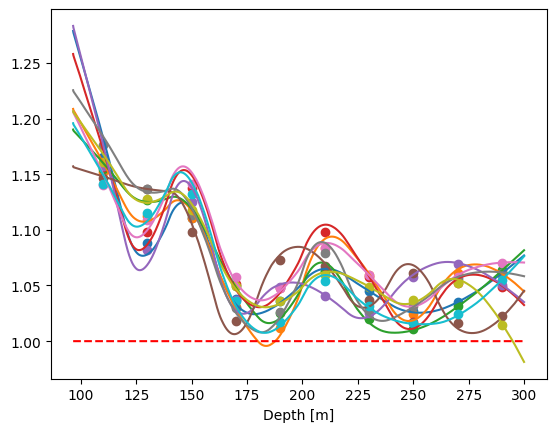

In [60]:
for X in x:
    plt.plot(Prop.z[Prop.i_start:],(X @ CO_avg_inv_interp) @ (f_avg @ C_flow_interp[0])/(f_avg@C_flow_poly[0,0]))
    plt.scatter(Prop.z_samp,X/CO_avg_poly[0,0])
plt.plot(Prop.z[Prop.i_start:],f_avg@C_flow_poly[0,0]/(f_avg@C_flow_poly[0,0]),ls='--',c='r')
plt.xlabel('Depth [m]')

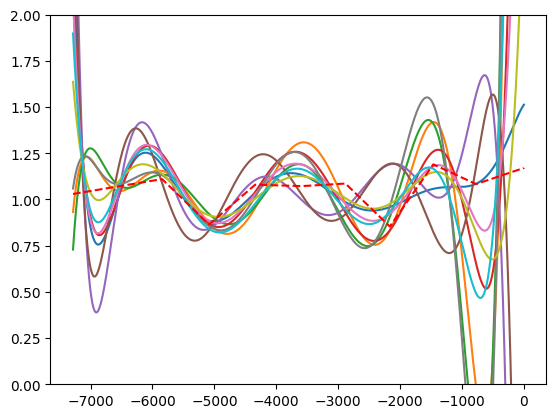

In [61]:
for X in x:
    plt.plot(t, (X @ CO_avg_inv_poly) @ f_poly)
plt.plot(t, f_samp @ f_interp, ls='--', c='r')
plt.ylim((0,2))
plt.show()

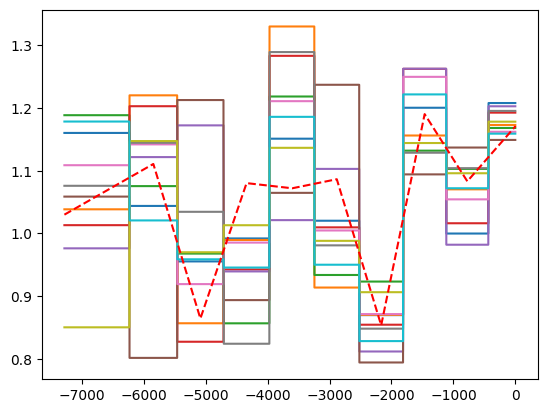

In [62]:
for X in x:
    plt.plot(t, (X @ CO_avg_inv_step) @ f_step)
plt.plot(t, f_samp @ f_interp, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

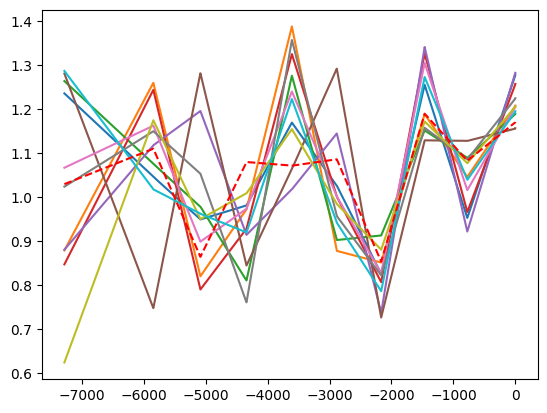

In [63]:
for X in x:
    plt.plot(t, (X @ CO_avg_inv_interp) @ f_interp)
plt.plot(t, f_samp @ f_interp, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

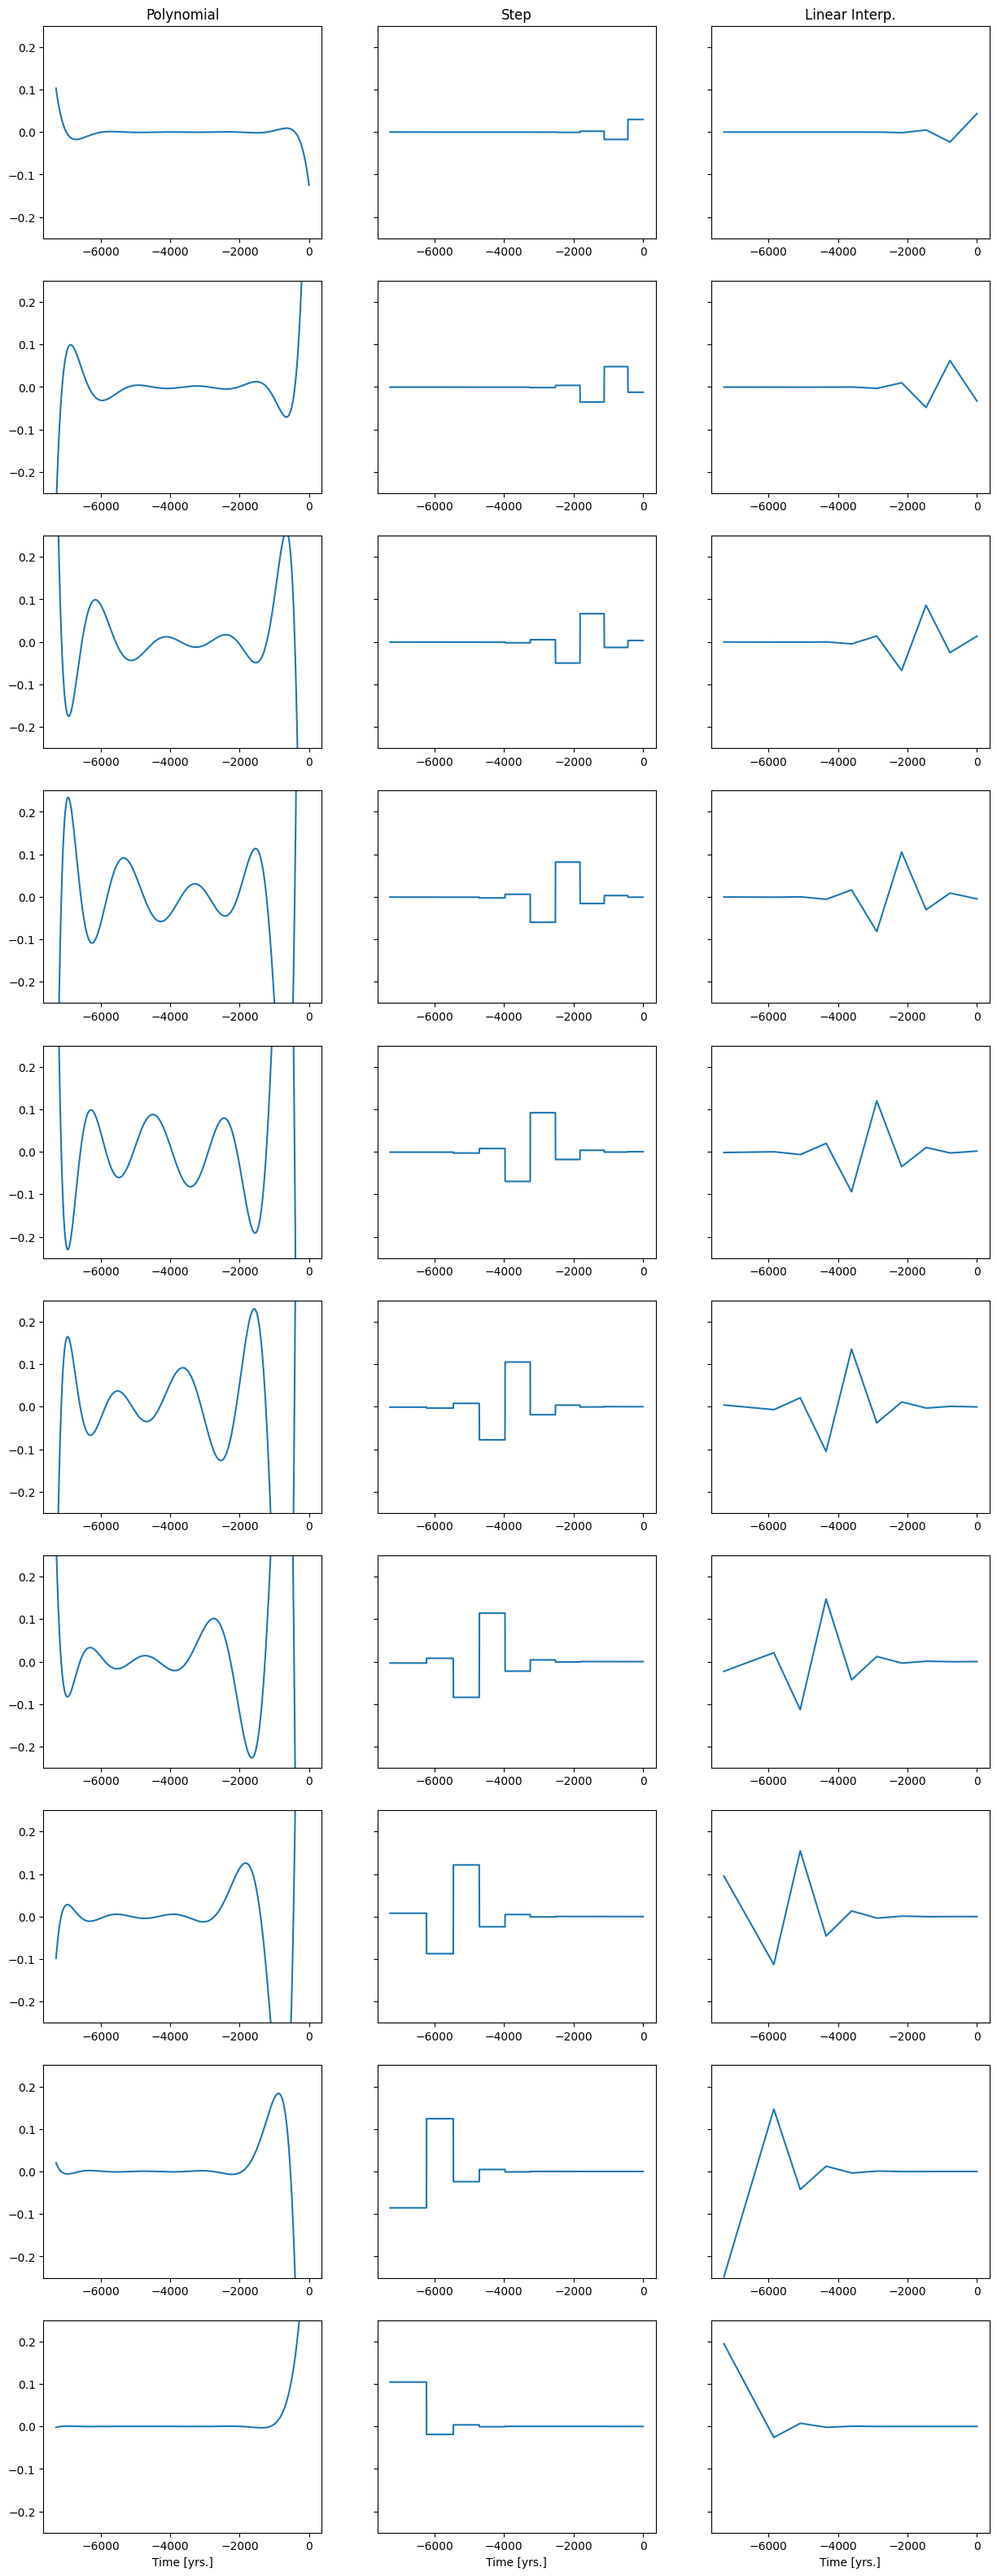

In [29]:
fig, ax = plt.subplots(np.shape(x)[-1],3, figsize=(15,40), sharey=True)
for i,X in enumerate(np.diag(CO_avg_poly[0,0]*rel_err) @ CO_avg_inv_poly @ f_poly):
    ax[i,0].plot(t, X)
    ax[i,0].set_ylim((-0.3,0.3))
for i,X in enumerate(np.diag(CO_avg_poly[0,0]*rel_err) @ CO_avg_inv_step @ f_step):
    ax[i,1].plot(t, X)
    ax[i,1].set_ylim((-0.3,0.3))
for i,X in enumerate(np.diag(CO_avg_poly[0,0]*rel_err) @ CO_avg_inv_interp @ f_interp):
    ax[i,2].plot(t, X)
    ax[i,2].set_ylim((-0.25,0.25))
ax[0,0].set_title('Polynomial')
ax[0,1].set_title('Step')
ax[0,2].set_title('Linear Interp.')
ax[-1,0].set_xlabel('Time [yrs.]')
ax[-1,1].set_xlabel('Time [yrs.]')
ax[-1,2].set_xlabel('Time [yrs.]')
plt.show()

In [64]:
#X = x[2]
#R = (f_avg @ np.swapaxes(C_response, 1,2))[0].T
R = CO_avg_step[0].T

unfold_results = [pu.iterative_unfold(
    data = X,
    data_err = X*rel_err,
    response = R,
    response_err = np.sqrt(abs(R)),
    efficiencies = np.sum(R,axis=0),
    efficiencies_err = np.sum(R,axis=0)*rel_err,
    #callbacks=[pu.Logger()],
    ts_stopping = 0.001  
) for X in x]

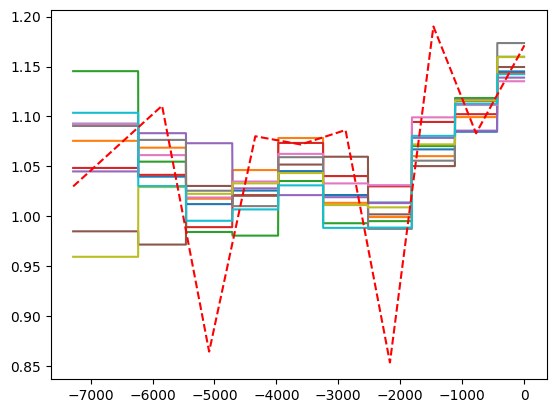

In [65]:
for u in unfold_results:
    plt.plot(t, u['unfolded'] @ f_step)
plt.plot(t, f_samp @ f_interp, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()